# Evaluación comparativa de arquitecturas Big Data

Objetivo: Construir una evaluación comparativa de alternativas arquitectónicas Big Data
a partir de evidencia experimental y criterios de selección. Este notebook contiene la
matriz de evaluación, el cálculo multicriterio simple, recomendaciones por escenario y
una discusión de trade-offs y limitaciones.

## Arquitecturas consideradas

Se comparan las siguientes alternativas (referencia):

- **A: Procesamiento local monolítico con archivos** (simple, bajo costo inicial).
- **B: Pipeline reproducible con Docker y almacenamiento columnar** (reproducible, optimizado para analítica).
- **C: Mini arquitectura con servicios conteinerizados** (microservicios ligeros, escalables).
- **D: Data lake / Lakehouse (conceptual)** (centralización de datos, flexibilidad de esquemas).
- **E: Arquitectura cloud o híbrida (conceptual)** (servicios gestionados, escalado elástico).

## Criterios y ponderaciones

Criterios usados (escala de 1 a 5, donde 5 es mejor) y ponderaciones (suma = 1):

- `rendimiento`: 0.16 — impacto en latencia y throughput.
- `costo_relativo`: 0.12 — coste total relativo (infraestructura y operación).
- `escalabilidad`: 0.15 — capacidad de crecer con volumen.
- `mantenibilidad`: 0.10 — facilidad para mantener y evolucionar.
- `reproducibilidad`: 0.10 — facilidad para reproducir pipelines/experimentos.
- `gobernanza`: 0.12 — control de datos, catálogo y linaje.
- `seguridad`: 0.10 — capacidad para proteger datos y accesos.
- `resiliencia`: 0.08 — tolerancia a fallos y recuperación.
- `complejidad_operativa`: 0.05 — coste operativo y overhead.
- `madurez_equipo`: 0.02 — nivel de experiencia requerido del equipo.

Justificación breve: las ponderaciones priorizan rendimiento, costo, escalabilidad y gobernanza porque
son determinantes al seleccionar infraestructuras Big Data; seguridad y resiliencia también
mantienen un peso relevante en contextos regulados.

Evidencia usada para la comparación:


,fuente,hallazgo,valor,unidad
0,Ejercicio 2,throughput CPU promedio,4860892.12637,pares/s
1,Ejercicio 2,relación binario/CSV en escritura,151.490978,x
2,Ejercicio 4,lecturas válidas en silver,9048,filas
3,Ejercicio 4,eventos válidos en silver,903,filas
4,Ejercicio 4,tasa de error lecturas/eventos,10.64% / 11.47%,porcentaje
5,Ejercicio 4,tablas gold generadas,3,tablas
6,Ejercicio 5,filas limpias en data lake local,9951,filas
7,Ejercicio 5,datasets parquet limpios,2,archivos



Matriz de evaluación basada en evidencia:


,rendimiento,costo_relativo,escalabilidad,mantenibilidad,reproducibilidad,gobernanza,seguridad,resiliencia,complejidad_operativa,madurez_equipo,soporte
Monolito archivos,3,5,1,1,1,1,1,2,5,5,Ej. 2 muestra que el procesamiento local puede...
Pipeline Docker columnar,5,4,3,4,5,3,3,3,3,4,"Ej. 2, 4 y 5 muestran la ventaja del formato b..."
Mini servicios conteinerizados,4,3,4,4,4,3,3,4,2,3,Ej. 5 muestra que la arquitectura contenerizad...
Data Lake/Lakehouse,4,3,5,4,4,4,4,4,2,2,"Ej. 4 y 5 aportan metadata, linaje, calidad y ..."
Cloud/Híbrida,5,2,5,4,4,5,5,5,2,3,No hay implementación directa; se usa como ext...



Ranking multicriterio:


,score_total,soporte
Cloud/Híbrida,4.25,No hay implementación directa; se usa como ext...
Data Lake/Lakehouse,3.89,"Ej. 4 y 5 aportan metadata, linaje, calidad y ..."
Pipeline Docker columnar,3.76,"Ej. 2, 4 y 5 muestran la ventaja del formato b..."
Mini servicios conteinerizados,3.54,Ej. 5 muestra que la arquitectura contenerizad...
Monolito archivos,2.16,Ej. 2 muestra que el procesamiento local puede...


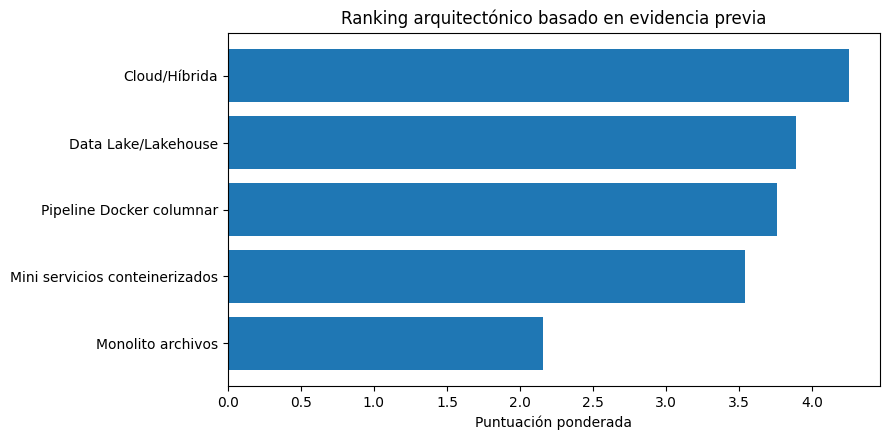

In [3]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd


def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        repo_candidate = candidate / 'parte_1_ejercicios'
        if repo_candidate.exists():
            return candidate
    raise FileNotFoundError(
        'No se encontró la carpeta parte_1_ejercicios desde el directorio actual ni sus padres.'
    )


repo_root = find_repo_root()
partes_root = repo_root / 'parte_1_ejercicios'

# Evidencia cuantitativa del ejercicio 2
bench_path = partes_root / 'ejercicio_02_benchmark_arquitectura' / 'resultados_benchmark.csv'
df_bench = pd.read_csv(bench_path)

cpu_mean = df_bench.loc[df_bench['escenario'] == 'cpu_nbody', 'throughput_pares_s'].mean()
bin_write_mean = df_bench.loc[df_bench['escenario'] == 'disco_escritura_binario', 'throughput_mb_s'].mean()
csv_write_mean = df_bench.loc[df_bench['escenario'] == 'disco_escritura_csv', 'throughput_mb_s'].mean()
ratio_binario_csv = bin_write_mean / csv_write_mean

# Evidencia del ejercicio 4
metadata_path = partes_root / 'ejercicio_04_pipeline_bigdata_docker' / 'metadata' / 'linaje.json'
calidad_path = partes_root / 'ejercicio_04_pipeline_bigdata_docker' / 'metrics' / 'reporte_calidad.json'
with metadata_path.open(encoding='utf-8') as metadata_file:
    linaje = json.load(metadata_file)
with calidad_path.open(encoding='utf-8') as calidad_file:
    calidad = json.load(calidad_file)

lecturas_validas_4 = int(calidad['fuentes']['lecturas_limpias']['filas_validas'])
eventos_validos_4 = int(calidad['fuentes']['eventos_limpios']['filas_validas'])
tasa_error_lecturas_4 = float(calidad['fuentes']['lecturas_limpias']['tasa_error_pct'])
tasa_error_eventos_4 = float(calidad['fuentes']['eventos_limpios']['tasa_error_pct'])
gold_tables_4 = len(linaje['etapas']['gold'])

# Evidencia del ejercicio 5
lecturas_5 = pd.read_parquet(partes_root / 'ejercicio_05_docker_compose_infraestructura' / 'datos' / 'lecturas_limpias.parquet')
eventos_5 = pd.read_parquet(partes_root / 'ejercicio_05_docker_compose_infraestructura' / 'datos' / 'eventos_limpios.parquet')
filas_total_5 = len(lecturas_5) + len(eventos_5)

resumen_evidencia = pd.DataFrame([
    {'fuente': 'Ejercicio 2', 'hallazgo': 'throughput CPU promedio', 'valor': cpu_mean, 'unidad': 'pares/s'},
    {'fuente': 'Ejercicio 2', 'hallazgo': 'relación binario/CSV en escritura', 'valor': ratio_binario_csv, 'unidad': 'x'},
    {'fuente': 'Ejercicio 4', 'hallazgo': 'lecturas válidas en silver', 'valor': lecturas_validas_4, 'unidad': 'filas'},
    {'fuente': 'Ejercicio 4', 'hallazgo': 'eventos válidos en silver', 'valor': eventos_validos_4, 'unidad': 'filas'},
    {'fuente': 'Ejercicio 4', 'hallazgo': 'tasa de error lecturas/eventos', 'valor': f'{tasa_error_lecturas_4:.2f}% / {tasa_error_eventos_4:.2f}%', 'unidad': 'porcentaje'},
    {'fuente': 'Ejercicio 4', 'hallazgo': 'tablas gold generadas', 'valor': gold_tables_4, 'unidad': 'tablas'},
    {'fuente': 'Ejercicio 5', 'hallazgo': 'filas limpias en data lake local', 'valor': filas_total_5, 'unidad': 'filas'},
    {'fuente': 'Ejercicio 5', 'hallazgo': 'datasets parquet limpios', 'valor': 2, 'unidad': 'archivos'},
])

print('Evidencia usada para la comparación:')
display(resumen_evidencia)

criteria = [
    'rendimiento', 'costo_relativo', 'escalabilidad', 'mantenibilidad', 'reproducibilidad',
    'gobernanza', 'seguridad', 'resiliencia', 'complejidad_operativa', 'madurez_equipo'
]
weights = {
    'rendimiento': 0.16,
    'costo_relativo': 0.12,
    'escalabilidad': 0.15,
    'mantenibilidad': 0.10,
    'reproducibilidad': 0.10,
    'gobernanza': 0.12,
    'seguridad': 0.10,
    'resiliencia': 0.08,
    'complejidad_operativa': 0.05,
    'madurez_equipo': 0.02,
}

scores = {
    'Monolito archivos': [3, 5, 1, 1, 1, 1, 1, 2, 5, 5],
    'Pipeline Docker columnar': [5, 4, 3, 4, 5, 3, 3, 3, 3, 4],
    'Mini servicios conteinerizados': [4, 3, 4, 4, 4, 3, 3, 4, 2, 3],
    'Data Lake/Lakehouse': [4, 3, 5, 4, 4, 4, 4, 4, 2, 2],
    'Cloud/Híbrida': [5, 2, 5, 4, 4, 5, 5, 5, 2, 3],
}

support = {
    'Monolito archivos': 'Ej. 2 muestra que el procesamiento local puede ser rápido, pero CSV es muy costoso y la reproducibilidad es baja.',
    'Pipeline Docker columnar': 'Ej. 2, 4 y 5 muestran la ventaja del formato binario/columnar, el entorno reproducible y el almacenamiento limpio en parquet.',
    'Mini servicios conteinerizados': 'Ej. 5 muestra que la arquitectura contenerizada facilita desacoplar ingesta, validación y consulta.',
    'Data Lake/Lakehouse': 'Ej. 4 y 5 aportan metadata, linaje, calidad y consulta sobre Parquet/MinIO/DuckDB.',
    'Cloud/Híbrida': 'No hay implementación directa; se usa como extrapolación de las capacidades vistas en 4 y 5.',
}

matrix = pd.DataFrame.from_dict(scores, orient='index', columns=criteria)
matrix['soporte'] = pd.Series(support)
matrix['score_total'] = matrix[criteria].mul(pd.Series(weights)).sum(axis=1)
matrix_sorted = matrix.sort_values('score_total', ascending=False)

print('\nMatriz de evaluación basada en evidencia:')
display(matrix[criteria + ['soporte']])

print('\nRanking multicriterio:')
display(matrix_sorted[['score_total', 'soporte']])

plt.figure(figsize=(9, 4.5))
plt.barh(matrix_sorted.index, matrix_sorted['score_total'], color='C0')
plt.xlabel('Puntuación ponderada')
plt.title('Ranking arquitectónico basado en evidencia previa')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Recomendaciones por escenario

Las recomendaciones siguientes se derivan del ranking y de las fortalezas/debilidades de cada alternativa: 

- **Equipo pequeño con recursos limitados:** `Monolito archivos` o `Pipeline Docker columnar` (si el equipo puede adoptar Docker). El monolito minimiza coste inicial y complejidad; el pipeline Docker aporta reproducibilidad si se puede asumir la curva de aprendizaje.
- **Organización con crecimiento de volumen:** `Cloud/Híbrida` o `Data Lake/Lakehouse`. Permiten escalado elástico y manejo de grandes volúmenes; elegir cloud gestionada reduce trabajo operativo pero aumenta coste relativo.
- **Organización regulada:** `Cloud/Híbrida` con enfoque en gobernanza o `Pipeline Docker columnar` con controles de linaje y catálogo; priorizar gobernanza y seguridad aún si sube coste.
- **Caso de datos semiestructurados / eventos continuos:** `Mini servicios conteinerizados` o `Cloud/Híbrida`. Arquitecturas por servicios facilitan ingestión continua y micro-batching/streaming; cloud brinda servicios gestionados para eventos.

## Discusión de trade-offs y limitaciones

- Las puntuaciones siguen siendo heurísticas, aunque ahora se apoyan en evidencia de ejercicios previos.
- Los pesos reflejan prioridades que pueden cambiar por escenario: en entornos regulados `gobernanza` y `seguridad` deberían recibir mayor peso.
- Las arquitecturas conceptuales (`Data Lake`, `Cloud`) requieren diseño detallado (servicios, configuración, proveedores) y por tanto su comparación aquí es de alto nivel.
- Recomendación metodológica: realizar experimentos controlados para medir `rendimiento`, `costo` y resiliencia por carga representativa, luego re-calibrar la matriz y repetir el ranking.